# Análisis estratégico y clustering de cartas: Wingspan

**Proyecto final — Diplomado en Transformación Digital Empresarial**  
**Autora:** Marcela Cadena  
**Fecha:** Junio 2026

---

## Pregunta de investigación

> ¿Qué grupos naturales emergen de los textos de poder de las cartas de Wingspan, y cómo se relacionan esos grupos con el tipo de activación, las mecánicas especiales y el hábitat del ave?

**Motivación estratégica:** Cada carta de Wingspan tiene un poder descrito en texto libre. Ese texto contiene la esencia estratégica de la carta: qué hace, cuándo lo hace y qué recursos mueve. Si agrupamos las cartas según la similitud de sus poderes, podemos descubrir patrones que las reglas del juego no explicitan — y usarlos para tomar mejores decisiones en el *draft* inicial.

---

**Estructura del notebook:**
1. Problema y datos (15%)
2. Modelado y análisis (35%)
3. Interpretación de clusters (25%)
4. Conclusiones (15%)
5. Uso de IA (10%)

---
## 1. Problema y datos
### 1.1 Carga de datos

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

DATA_PATH = os.path.join(os.path.dirname(os.getcwd()), 'data', 'raw', 'wingspan-20260128.xlsx')

# Las filas 1 y 2 del Excel contienen estadísticas internas, no cartas.
df_raw = pd.read_excel(DATA_PATH, sheet_name='Birds', skiprows=[1, 2])

print(f'Dimensiones del dataset: {df_raw.shape}')
df_raw.head(3)

Dimensiones del dataset: (707, 65)


,Common name,Scientific name,Set,Color,Power text,Predator,Flocking,Bonus card,Victory points,Nest type,...,Nest Box Builder,Omnivore Expert,Passerine Specialist,Platform Builder,Prairie Manager,Rodentologist,Small Clutch Specialist,Viticulturalist,Wetland Scientist,Wildlife Gardener
0,Abbott's Booby,Papasula abbotti,oceania,white,"Draw 3 bonus cards, then discard 2. You may di...",NaN,NaN,X,5,platform,...,NaN,NaN,NaN,X,NaN,NaN,X,NaN,X,NaN
1,Acadian Flycatcher,Empidonax virescens,promoUS,brown,Draw and discard 1 [card] from the deck. If it...,NaN,NaN,NaN,2,wild,...,X,NaN,X,X,NaN,NaN,X,NaN,NaN,X
2,Acorn Woodpecker,Melanerpes formicivorus,core,brown,"Gain 1 [seed] from the birdfeeder, if availabl...",NaN,NaN,NaN,5,cavity,...,X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.2 Exploración del campo `Power text`

In [22]:
# Eliminar filas sin nombre de ave
df = df_raw.dropna(subset=['Common name']).reset_index(drop=True)
print(f'Total de cartas: {len(df)}')

# Cartas con y sin poder
con_poder = df['Power text'].notna().sum()
sin_poder = df['Power text'].isna().sum()
print(f'Cartas con Power text:  {con_poder} ({con_poder/len(df)*100:.1f}%)')
print(f'Cartas sin Power text:  {sin_poder} ({sin_poder/len(df)*100:.1f}%)')

Total de cartas: 707
Cartas con Power text:  701 (99.2%)
Cartas sin Power text:  6 (0.8%)


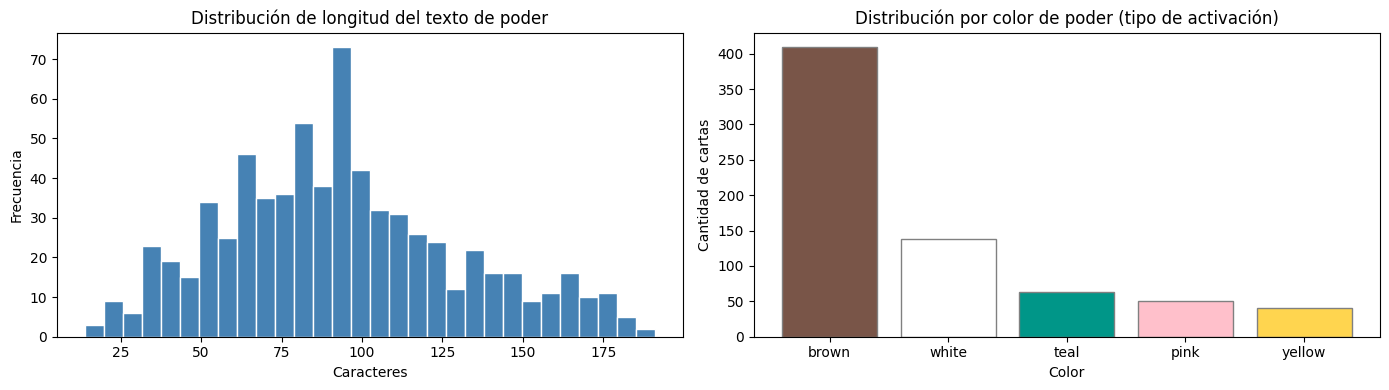

In [23]:
# Longitud del texto de poder
df['power_length'] = df['Power text'].fillna('').apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[df['power_length'] > 0]['power_length'], bins=30,
             color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de longitud del texto de poder')
axes[0].set_xlabel('Caracteres')
axes[0].set_ylabel('Frecuencia')

color_counts = df['Color'].value_counts()
axes[1].bar(color_counts.index, color_counts.values,
            color=['#795548', '#FFFFFF', '#009688', '#FFC0CB', '#FFD54F'],
            edgecolor='gray')
axes[1].set_title('Distribución por color de poder (tipo de activación)')
axes[1].set_xlabel('Color')
axes[1].set_ylabel('Cantidad de cartas')

plt.tight_layout()
plt.show()

En Wingspan cada color indica cuándo se activa el poder de la carta:

| Color | Cuándo se activa | Ejemplo de poder |
| :--- | :--- | :--- |
| <strong style="color: #795548;">Marrón (Brown)</strong> | Cada vez que activas el hábitat donde está el ave | "Lay 1 egg on each bird in this habitat" |
| <strong style="color: #FFC0CB;">Rosa (Pink)</strong> | Una vez entre turnos, cuando otro jugador activa ese hábitat | "When another player plays a bird here, gain 1 food" |
| <strong style="color: #FFFFFF; background-color: #9E9E9E; padding: 2px 4px; border-radius: 3px;">Blanco (White)</strong> | Solo al momento de jugar la carta, una única vez | "Draw 3 bonus cards, then discard 2" |
| <strong style="color: #009688;">Verde azulado (Teal)</strong> | Al final de cada ronda | "Tuck 1 card from your hand behind this bird" |
| <strong style="color: #FFD54F;">Amarillo (Yellow)</strong> | Al final de la partida | "Calculate score for this bird based on eggs in its habitat" |
| **Sin color** | Nunca — es información pasiva | Solo indica puntos base o condiciones de bonificación |

---

**Importante considerar:**

- Las cartas <strong style="color: #795548;">marrón</strong> son el corazón de cualquier motor porque su poder se repite múltiples veces por partida — cuanto más a la izquierda estén en el tablero, más veces se activan. 
- Las <strong style="color: #FFC0CB;">rosa</strong> acumulan recursos pasivamente sin gastar tu turno. 
- Las <strong style="color: #FFFFFF; background-color: #9E9E9E; padding: 2px 4px; border-radius: 3px;">blanco</strong> y <strong style="color: #009688;">verde azulado</strong> son poderes de apoyo, no de motor. 
- Finalmente, las cartas <strong style="color: #FFD54F;">amarillo</strong> te permiten capitalizar estrategias y obtener puntos masivos al terminar el juego.

In [24]:
# Resumen: distribución por color en cada Set
from IPython.display import display

counts = df.groupby(['Set', 'Color']).size().unstack(fill_value=0)
counts['Total'] = counts.sum(axis=1)

pct = counts.div(counts['Total'], axis=0).multiply(100).round(1)

color_cols = [c for c in counts.columns if c != 'Total']
formatted = counts[color_cols].astype(str) + ' (' + pct[color_cols].astype(str) + '%)'
formatted['Total'] = counts['Total']

formatted = formatted.sort_values('Total', ascending=False)

# Quitar el título "Color" que aparece sobre las columnas
formatted.columns.name = None

print("Distribución por Color dentro de cada Set (conteo (porcentaje%))\n")
display(formatted.reset_index())


Distribución por Color dentro de cada Set (conteo (porcentaje%))



,Set,brown,pink,teal,white,yellow,Total
0,core,125 (71.8%),12 (6.9%),0 (0.0%),37 (21.3%),0 (0.0%),174
1,americas,67 (60.4%),11 (9.9%),12 (10.8%),16 (14.4%),5 (4.5%),111
2,oceania,59 (62.1%),5 (5.3%),0 (0.0%),15 (15.8%),16 (16.8%),95
3,asia,54 (60.0%),2 (2.2%),16 (17.8%),15 (16.7%),3 (3.3%),90
4,european,38 (46.9%),5 (6.2%),20 (24.7%),18 (22.2%),0 (0.0%),81
5,promoAsia,12 (48.0%),2 (8.0%),2 (8.0%),6 (24.0%),3 (12.0%),25
6,promoCA,12 (48.0%),2 (8.0%),3 (12.0%),6 (24.0%),2 (8.0%),25
7,promoEurope,11 (44.0%),3 (12.0%),3 (12.0%),5 (20.0%),3 (12.0%),25
8,promoNZ,11 (44.0%),2 (8.0%),1 (4.0%),9 (36.0%),2 (8.0%),25
9,promoUK,8 (32.0%),4 (16.0%),4 (16.0%),5 (20.0%),4 (16.0%),25


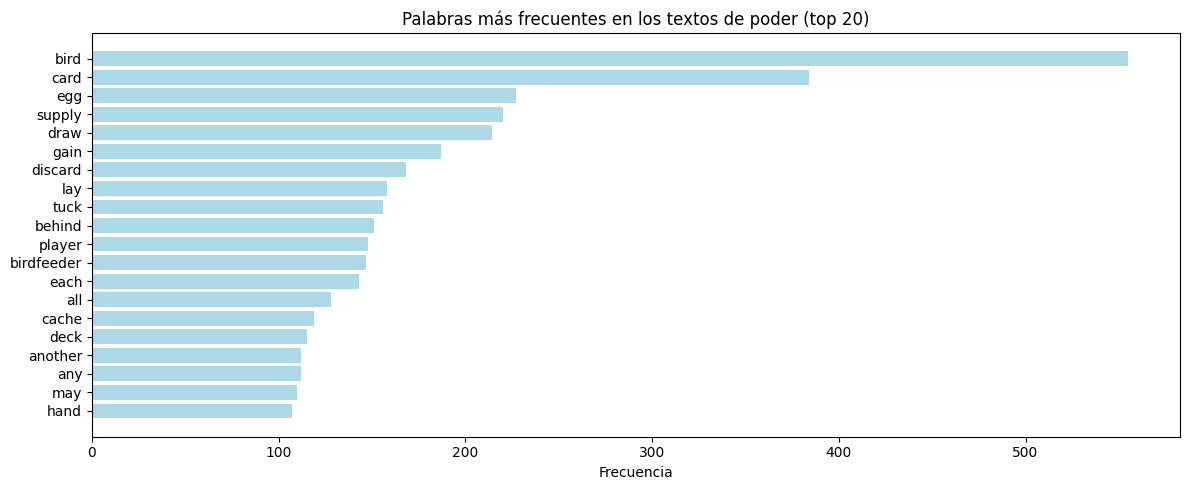

In [25]:
# Palabras más frecuentes en los textos de poder
from collections import Counter

# Palabras vacías a ignorar (stop words del dominio)
stop_words = {
      'the', 'a', 'an', 'this', 'that', 'of', 'in', 'on', 'to', 'from',
      'for', 'with', 'and', 'you', 'your', 'it', 'its', 'at', 'than',
      'then', 'is', 'are', 'be', 'as', 'up', 'per'
  }

all_words = []
for text in df['Power text'].dropna():
    words = re.findall(r'[a-z]+', text.lower())
    all_words.extend([w for w in words if w not in stop_words and len(w) > 2])

top_words = Counter(all_words).most_common(20)
words, counts = zip(*top_words)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(list(reversed(words)), list(reversed(counts)), color='lightblue')
ax.set_title('Palabras más frecuentes en los textos de poder (top 20)')
ax.set_xlabel('Frecuencia')
plt.tight_layout()
plt.show()

 **Una definicion importante:**
 
 Un **motor** en Wingspan es una estrategia de combo que un jugador construye a lo largo de la partida al colocar aves cuyo poderes se encadenan entre sí. Cada vez que activas un hábitat, las aves marrones (🟫) de esa fila se disparan en cascada de derecha a izquierda, generando recursos de forma exponencial. Un motor bien construido convierte cada turno en una cadena de acciones que produce más de lo que consume — huevos, alimento o cartas — creando una ventaja acumulativa que se vuelve difícil de remontar.
  
### Interpretación 

Las palabras más frecuentes revelan las mecánicas dominantes del juego: `egg`, `draw`, `food`, `cache`, `lay`, `tuck`. Estas son exactamente las acciones que definen los tres motores principales. 

La distribución de longitud del texto muestra que la mayoría de los poderes son descripciones cortas (menos de 150 caracteres), lo que sugiere vocabulario repetido y patrones claros para el clustering.

### 1.3 Limpieza y preparación del texto

In [26]:
def clean_power_text(text):
    if pd.isna(text):
        return ''
    # Minúsculas
    text = text.lower()
    # Reemplazar símbolos de recursos del juego por palabras legibles
    text = re.sub(r'\[invertebrate\]', 'invertebrate', text)
    text = re.sub(r'\[seed\]', 'seed', text)
    text = re.sub(r'\[fish\]', 'fish', text)
    text = re.sub(r'\[fruit\]', 'fruit', text)
    text = re.sub(r'\[rodent\]', 'rodent', text)
    text = re.sub(r'\[nectar\]', 'nectar', text)
    text = re.sub(r'\[wild\]', 'wild', text)
    text = re.sub(r'\[egg\]', 'egg', text)
    text = re.sub(r'\[card\]', 'card', text)
    # Eliminar caracteres no alfabéticos
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Colapsar espacios múltiples
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['power_clean'] = df['Power text'].apply(clean_power_text)

# Separar cartas con y sin poder para el análisis
df_con_poder = df[df['power_clean'] != ''].reset_index(drop=True)
df_sin_poder = df[df['power_clean'] == ''].reset_index(drop=True)

print(f'Cartas con poder (entran al clustering): {len(df_con_poder)}')
print(f'Cartas sin poder (excluidas del clustering): {len(df_sin_poder)}')
print(f'\nEjemplo de texto limpio:')
print(df_con_poder[['Common name', 'Power text', 'power_clean']].head(3).to_string())

Cartas con poder (entran al clustering): 701
Cartas sin poder (excluidas del clustering): 6

Ejemplo de texto limpio:
          Common name                                                                                                                                                                          Power text                                                                                                                                                        power_clean
0      Abbott's Booby                                                                                         Draw 3 bonus cards, then discard 2. You may discard bonus cards you did not draw this turn.                                                                               draw bonus cards then discard you may discard bonus cards you did not draw this turn
1  Acadian Flycatcher  Draw and discard 1 [card] from the deck. If it has [invertebrate] in its food cost, gain 1 [invertebrate] from the supply and cac

**Nota:** Las cartas sin poder son aves con valor puramente estático (solo suman puntos base al final). Se excluyen del clustering porque no aportan información textual, pero se analizan como grupo separado en la sección de interpretación.

## 2. Modelado y análisis
### 2.1 Vectorización con TF-IDF

Se vectoriza el campo de texto de los poderes con TF-IDF (Term Frequency — Inverse Document Frequency).

> **Explicación del Modelo: TF-IDF**
> 
> **TF-IDF** (*Term Frequency — Inverse Document Frequency*) es una técnica de vectorización de texto que convierte cada carta en un vector numérico. Asigna un peso alto a las palabras que son frecuentes en una carta específica pero raras en el resto del corpus — lo que las hace distintivas. 
> 
> En este análisis, una palabra como `cache` tendrá peso alto en las cartas que la usan porque no aparece en todas, mientras que palabras genéricas como `bird` se eliminan previamente. El resultado es una matriz donde cada fila es una carta y cada columna es una palabra, lista para ser procesada por los algoritmos de clustering.

Cada carta queda representada como un vector numérico donde cada dimensión es una palabra, ponderada por qué tan distintiva es en esa carta respecto al resto del corpus.

**Parámetros elegidos:**
- `max_features=200`: limita el vocabulario a las 200 características más informativas del corpus.
- `ngram_range=(1, 2)`: incluye unigramas, bigramas y trigramas (ej. `lay egg`, `draw cards`) que capturan mecánicas compuestas. ---> Le decimos al modelo algo como "Analiza el peso de cada palabra individual (1), pero también analiza el peso de cada par de palabras que aparezcan juntas (2)".
- `min_df=3`: ignora términos que aparecen en menos de 3 cartas (ruido).
- `sublinear_tf=True`: usa escala logaritmica para evitar que textos largos dominen. ---> En términos sencillos, significa que las primeras veces que aparece una palabra suman mucho valor, pero las repeticiones adicionales suman cada vez menos. Esto es importnte ya que en Wingspan, algunas aves tienen poderes muy sencillos y textos cortos, mientras que otras tienen condiciones complejas y textos largos.

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=200,
    ngram_range=(1, 3),
    min_df=3,
    sublinear_tf=True
)

X_tfidf = tfidf.fit_transform(df_con_poder['power_clean'])

print(f'Matriz TF-IDF: {X_tfidf.shape}')
print(f'  {X_tfidf.shape[0]} cartas x {X_tfidf.shape[1]} términos')
print('Primeros 30 términos del vocabulario:')
print(tfidf.get_feature_names_out()[:30])

Matriz TF-IDF: (701, 200)
  701 cartas x 200 términos
Primeros 30 términos del vocabulario:
['action' 'additional' 'all' 'all players' 'an' 'and' 'and discard'
 'and keep' 'another' 'another bird' 'another player' 'any' 'are' 'at'
 'at least' 'at the' 'at the end' 'available' 'behind' 'behind this'
 'behind this bird' 'bird' 'bird if' 'bird if you' 'bird in'
 'bird in your' 'bird with' 'birdfeeder' 'birdfeeder if' 'birds']


### 2.2 Reducción de dimensionalidad

Como es imposible visualizar agrupaciones en un espacio de 200 dimensiones, aplicamos una reducción de dimensionalidad en dos etapas:

- **PCA (Análisis de Componentes Principales):** Actúa como un filtro de ruido (paso previo). Reducimos el espacio a **50 dimensiones**, lo cual nos permite conservar aproximadamente el **83% de la varianza** original de los datos. 
Esta cantidad es ideal porque retiene la información de las mecánicas clave de las aves, al mismo tiempo que descarta el "ruido" matemático (palabras demasiado raras o mecánicas aisladas) antes de pasar al siguiente algoritmo.

- **t-SNE (t-Distributed Stochastic Neighbor Embedding):** Comprime las 50 dimensiones obtenidas del PCA a un plano de **2 dimensiones** para poder graficarlas. Su principal fortaleza es que preserva las relaciones locales; en el contexto de *Wingspan*, esto garantiza que las aves con mecánicas de juego muy similares (como los motores de recolección de alimento o las estrategias de poner huevos) queden físicamente cerca unas de otras en la visualización. Es la herramienta ideal para revelar de forma gráfica las distintas sinergias y familias de cartas dentro del juego.

> **¿Es necesario estandarizar antes de PCA?**
>
> No en este caso. `TfidfVectorizer` aplica normalización L2 por defecto (`norm='l2'`), lo que significa que cada vector de carta ya tiene norma 1 — todas las cartas están en la misma escala antes de entrar a PCA.
>
> Aplicar `StandardScaler` sobre una matriz TF-IDF tendría un efecto negativo: centraría cada término en 0 convirtiendo los ceros (la mayoría de las celdas, dado el vocabulario disperso) en valores negativos, destruyendo la sparsity que hace eficiente el cálculo y distorsionando la geometría que PCA necesita para encontrar las direcciones de mayor varianza.

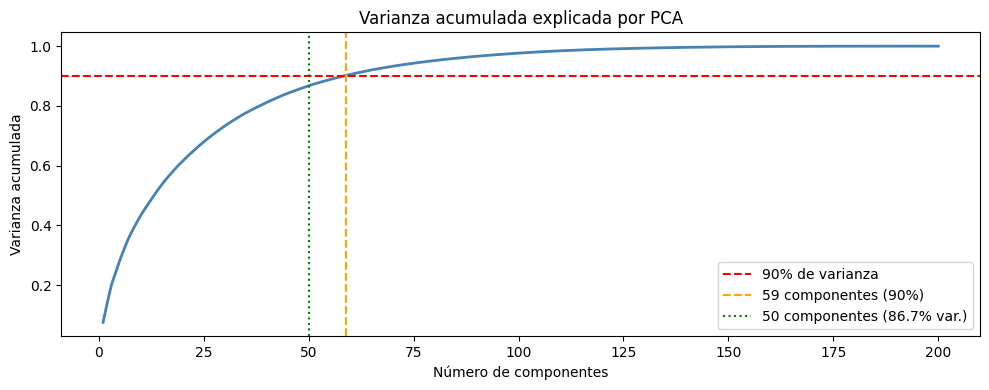

Componentes necesarios para alcanzar el 90% de varianza: 59
Varianza real retenida con 50 componentes: 86.74%


In [28]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

## Exploración...
pca_completo = PCA(random_state=RANDOM_STATE)
pca_completo.fit(X_tfidf.toarray())

varianza_acumulada = pca_completo.explained_variance_ratio_.cumsum()

componentes_90 = (varianza_acumulada >= 0.90).argmax() + 1
varianza_50 = varianza_acumulada[49] # Índice 49 corresponde a 50 componentes

### Gráfica
fig, ax = plt.subplots(figsize=(10, 4))

# Línea de la curva de varianza
ax.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, color='steelblue', linewidth=2)

# Línea del objetivo del 90%
ax.axhline(0.90, color='red', linestyle='--', label='90% de varianza')

# Línea vertical donde realmente se alcanza el 90%
ax.axvline(componentes_90, color='orange', linestyle='--',
           label=f'{componentes_90} componentes (90%)')

# Línea vertical para tu límite original de 50 componentes
ax.axvline(50, color='green', linestyle=':', 
           label=f'50 componentes ({varianza_50:.1%} var.)')

ax.set_title('Varianza acumulada explicada por PCA')
ax.set_xlabel('Número de componentes')
ax.set_ylabel('Varianza acumulada')
ax.legend()
plt.tight_layout()
plt.show()


print(f'Componentes necesarios para alcanzar el 90% de varianza: {componentes_90}')
print(f'Varianza real retenida con 50 componentes: {varianza_50:.2%}')

## Decisión...
X_pca = PCA(n_components=50, random_state=RANDOM_STATE).fit_transform(X_tfidf.toarray())

### Configuración del modelo t-SNE
Para mapear las sinergias entre las cartas, configuramos el algoritmo t-SNE con los siguientes parámetros clave:

* **`n_components=2`:** Reduce las 50 dimensiones extraídas por el PCA a solo dos coordenadas (X, Y). Esto nos permite proyectar el motor de juego completo en un plano bidimensional (un mapa plano) donde cada punto representará un ave.
* **`perplexity=40`:** Es el parámetro que define el tamaño del "vecindario" de cada carta. Al ajustarlo a 40, le indicamos al algoritmo que cada ave debe buscar agruparse con aproximadamente 40 cartas de mecánicas afines. Para un mazo del tamaño de *Wingspan*, este valor es ideal para consolidar familias estratégicas lógicas (ej. motores de huevos o motores de robo) sin fragmentarlas en micro-grupos irrelevantes.
* **`max_iter=1000`:** Define el límite de tiempo que tiene el algoritmo para "jalonear" los datos. Le otorga hasta 1,000 repeticiones para que las fuerzas de atracción entre cartas similares estabilicen los clústeres en el mapa.
* **`random_state=RANDOM_STATE`:** Fija una semilla matemática inicial. Dado que t-SNE es un algoritmo estocástico (con un componente aleatorio), esto garantiza la **reproducibilidad** de nuestro análisis: el mapa de las aves se dibujará exactamente igual cada vez que ejecutemos el código.

In [29]:
from sklearn.manifold import TSNE
import plotly.express as px

# ── 1. Ajustar t-SNE sobre la matriz PCA 
tsne = TSNE(
    n_components=2,
    perplexity=40,
    random_state=RANDOM_STATE,
    max_iter=1000,
)
X_tsne = tsne.fit_transform(X_pca)

# ── 2. Agregar coordenadas al DataFrame 
df_con_poder['tsne_x'] = X_tsne[:, 0]
df_con_poder['tsne_y'] = X_tsne[:, 1]

# ── 3. Scatter interactivo con hover 
fig_tsne = px.scatter(               # nombre distinto para no pisar el fig de matplotlib
    df_con_poder,
    x='tsne_x',
    y='tsne_y',
    color='Color',                   # colorea por tipo de activación, no por cluster
    hover_name='Common name',        # aparece en negritas al hacer hover
    hover_data={
        'power_clean': True,         # muestra descripción del poder
        'tsne_x': False,             # oculta coordenadas brutas del hover
        'tsne_y': False,
    },
    title='Espacio t-SNE — hover para ver nombre y poder',
    color_discrete_map={            
        'brown':  '#795548',
        'pink':   '#E91E63',
        'white':  '#BDBDBD',
        'teal':   '#009688',
        'yellow': '#FFC107',
    },
    height=650,
)

fig_tsne.update_traces(marker=dict(size=7, opacity=0.75))
fig_tsne.update_layout(legend_title_text='Color de activación')
fig_tsne.show()

In [ ]:
# Versión estática para visualización en GitHub (matplotlib)
color_palette = {
    'brown':  '#795548',
    'pink':   '#E91E63',
    'white':  '#BDBDBD',
    'teal':   '#009688',
    'yellow': '#FFC107',
}

fig, ax = plt.subplots(figsize=(11, 7))

for color_val, group in df_con_poder.groupby('Color'):
    ax.scatter(
        group['tsne_x'], group['tsne_y'],
        c=color_palette.get(str(color_val).lower(), '#9E9E9E'),
        label=color_val, alpha=0.7, s=15
    )

ax.set_title('Espacio t-SNE — cartas coloreadas por tipo de activación')
ax.set_xlabel('t-SNE dimensión 1')
ax.set_ylabel('t-SNE dimensión 2')
ax.legend(title='Color de activación', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Interpretación 

Recordemos que el algoritmo NO sabía de qué color eran las cartas cuando las agrupó. Las organizó basándose 100% en las palabras de sus poderes.

¿Qué observamos?
- Los puntos marrones están esparcidos por casi todo el mapa, formando múltiples clústeres diferentes (recordemos que son el motor del juego).
- Hay grupos definidos que se forman en los extremos izquierdos (tanto arriba como abajo) y son casi exclusivamente de puntos blancos o grises.
- Observamos los pequeños pero muy compactos grupos de puntos rosas (por ejemplo, en la parte superior central y en la parte inferior derecha).
- Las cartas amarillas de fin de partida (puntos dorados) tienden a agruparse en regiones específicas, probablemente porque comparten textos relacionados con conteos masivos (ej. "Count the number of birds...").
- Las verde azuladas (fin de ronda) están más dispersas, lo que indica que, al igual que las marrones, sus beneficios (robar, poner, cazar) son variados, aunque a veces se pegan a las islas marrones que hacen acciones similares.


### 2.3 K-means: elección del número de clusters

> **Nota metodológica:** t-SNE es un algoritmo estocástico que no genera una función
> matemática reversible — no puede proyectar datos nuevos de forma consistente y por lo
> tanto no debe usarse como preprocesador para ningún modelo de ML. Su único uso válido
> es la visualización exploratoria.
>
> Tanto K-Means como DBSCAN se entrenan sobre **`X_pca`** (determinista, reproducible,
> exportable). El espacio t-SNE se usa exclusivamente para graficar los resultados.

Se usa el **método del codo** (inercia) y el **silhouette score** para elegir $k$.
El silhouette score mide qué tan bien separados están los clusters (1 = perfecto, -1 = solapados).

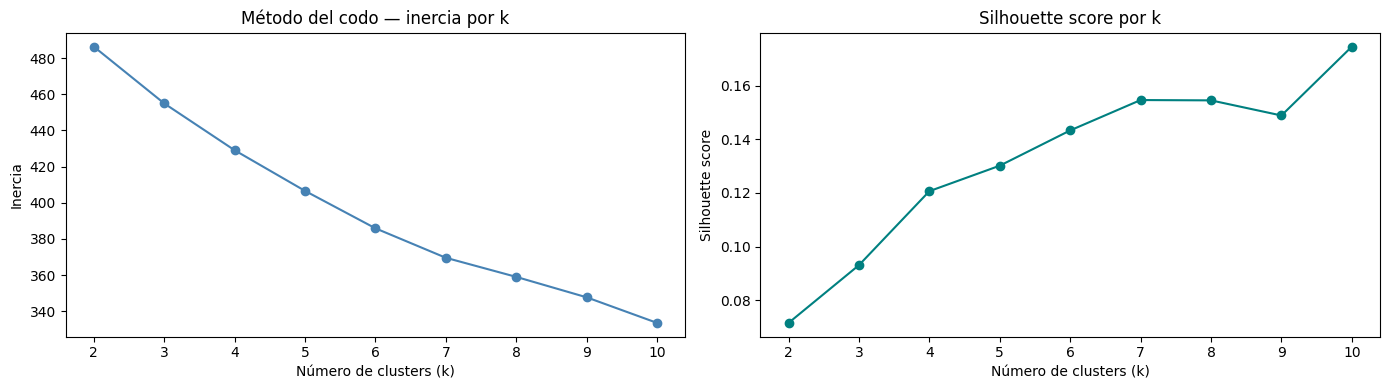

k con mejor silhouette score: 10 (0.1745)


In [30]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inercias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_pca) # usa PCA
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(k_range, inercias, marker='o', color='steelblue')
axes[0].set_title('Método del codo — inercia por k')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')

axes[1].plot(k_range, silhouettes, marker='o', color='teal')
axes[1].set_title('Silhouette score por k')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette score')

plt.tight_layout()
plt.show()

mejor_k = k_range[silhouettes.index(max(silhouettes))]
print(f'k con mejor silhouette score: {mejor_k} ({max(silhouettes):.4f})')

### Interpretación 

1. Gráfica de Inercia (Método del codo)
- No hay un codo claro; baja de forma suave y continua.
Esto hace sentido ya que nos indica que las cartas del juego no están aisladas en categorías rígidas y perfectas, sino que existe un espectro fluido de mecánicas. Muchas cartas hacen cosas híbridas (ej. "roba 1 carta y pon 1 huevo"), lo que suaviza la curva porque los grupos se entrelazan.

2. Gráfica de Silhouette Score
- El pico en K=10: El modelo identifica que el mejor equilibrio matemático se alcanza dividiendo el mazo en 10 grupos (score de 0.1745).

    Pero **¿no es muy bajo el 0.17?** En procesamiento de lenguaje natural (NLP), los scores de Silhouette rara vez superan el 0.2 o 0.3. Como las cartas comparten palabras comunes de apoyo matemático o del tablero, los clústeres siempre van a estar cerca unos de otros geométricamente. Un 0.17 para texto es un resultado totalmente válido y trabajable.

### 2.4 K-means final

In [31]:
# Entrenar K-means con el k elegido (k=10)

k_final = mejor_k

km_final = KMeans(n_clusters=k_final, random_state=RANDOM_STATE, n_init=10)
df_con_poder['cluster_kmeans'] = km_final.fit_predict(X_pca) # usa PCA

print(f'Clusters K-means (k={k_final}):')
print(df_con_poder['cluster_kmeans'].value_counts().sort_index())

Clusters K-means (k=10):
cluster_kmeans
0     30
1     86
2    100
3     74
4     32
5     54
6     96
7     69
8     53
9    107
Name: count, dtype: int64


### 2.5 DBSCAN

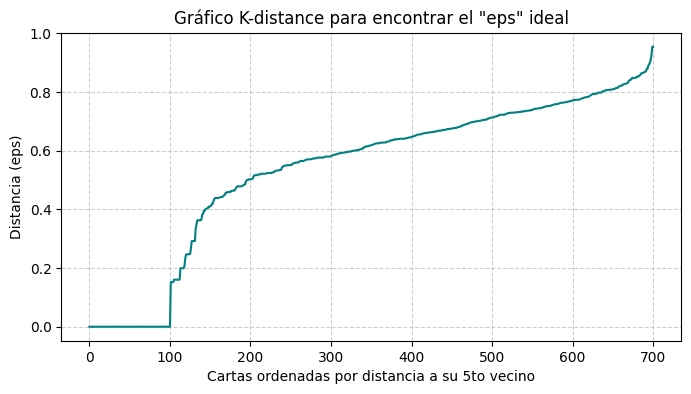

In [45]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# 1. Calculamos la distancia de cada carta a sus 5 vecinas más cercanas
# Usamos n_neighbors=5 porque tu min_samples en DBSCAN es 5
vecinos = NearestNeighbors(n_neighbors=5)
vecinos_fit = vecinos.fit(X_pca)
distancias, indices = vecinos_fit.kneighbors(X_pca)

# 2. Tomamos solo las distancias al 5to vecino y las ordenamos de menor a mayor
distancias_5to_vecino = np.sort(distancias[:, 4], axis=0)

# 3. Graficamos
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(distancias_5to_vecino, color='teal')
ax.set_title('Gráfico K-distance para encontrar el "eps" ideal')
ax.set_xlabel('Cartas ordenadas por distancia a su 5to vecino')
ax.set_ylabel('Distancia (eps)')
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Leyendo la gráfica:

1. **La zona plana (0.0):** Las primeras 100 cartas tienen una distancia de 0. Estos son clones absolutos (cartas con textos idénticos).
2. **El muro vertical (0.0 a 0.4):** De repente, la distancia se dispara. Aquí el algoritmo está batallando con las pequeñas diferencias de palabras.
3. **El "Codo" (donde nos interesa):** Justo entre el 0.4 y el 0.45 en el eje Y (Distancia), la curva se "rompe". La subida violenta se detiene y la línea empieza a formar una rampa mucho más suave y constante.

Nos decidimos por un eps=0.45

In [49]:
from sklearn.cluster import DBSCAN

# DBSCAN entrenado sobre X_pca — mismo espacio que K-Means.
# t-SNE NO se usa aquí: es estocástico, no reproducible y no admite nuevos datos.
# El eps se ajusta a la escala de PCA (valores típicos entre 0.5 y 3.0).
dbscan = DBSCAN(eps=0.45, min_samples=5)
df_con_poder['cluster_dbscan'] = dbscan.fit_predict(X_pca)

n_clusters_db = len(set(df_con_poder['cluster_dbscan'])) - (1 if -1 in df_con_poder['cluster_dbscan'].values else 0)
n_ruido = (df_con_poder['cluster_dbscan'] == -1).sum()

print(f'Clusters encontrados por DBSCAN: {n_clusters_db}')
print(f'Puntos de ruido (etiqueta -1): {n_ruido} ({n_ruido/len(df_con_poder)*100:.1f}%)')
print(f'Distribución de clusters DBSCAN:')
print(df_con_poder['cluster_dbscan'].value_counts().sort_index())

Clusters encontrados por DBSCAN: 23
Puntos de ruido (etiqueta -1): 513 (73.2%)
Distribución de clusters DBSCAN:
cluster_dbscan
-1     513
 0       6
 1       8
 2       9
 3       5
 4       7
 5      12
 6       7
 7      10
 8      17
 9       5
 10     12
 11      8
 12      8
 13     10
 14      8
 15     10
 16      7
 17      6
 18      5
 19     12
 20      5
 21      5
 22      6
Name: count, dtype: int64


### 2.6 Comparación visual: K-means vs DBSCAN

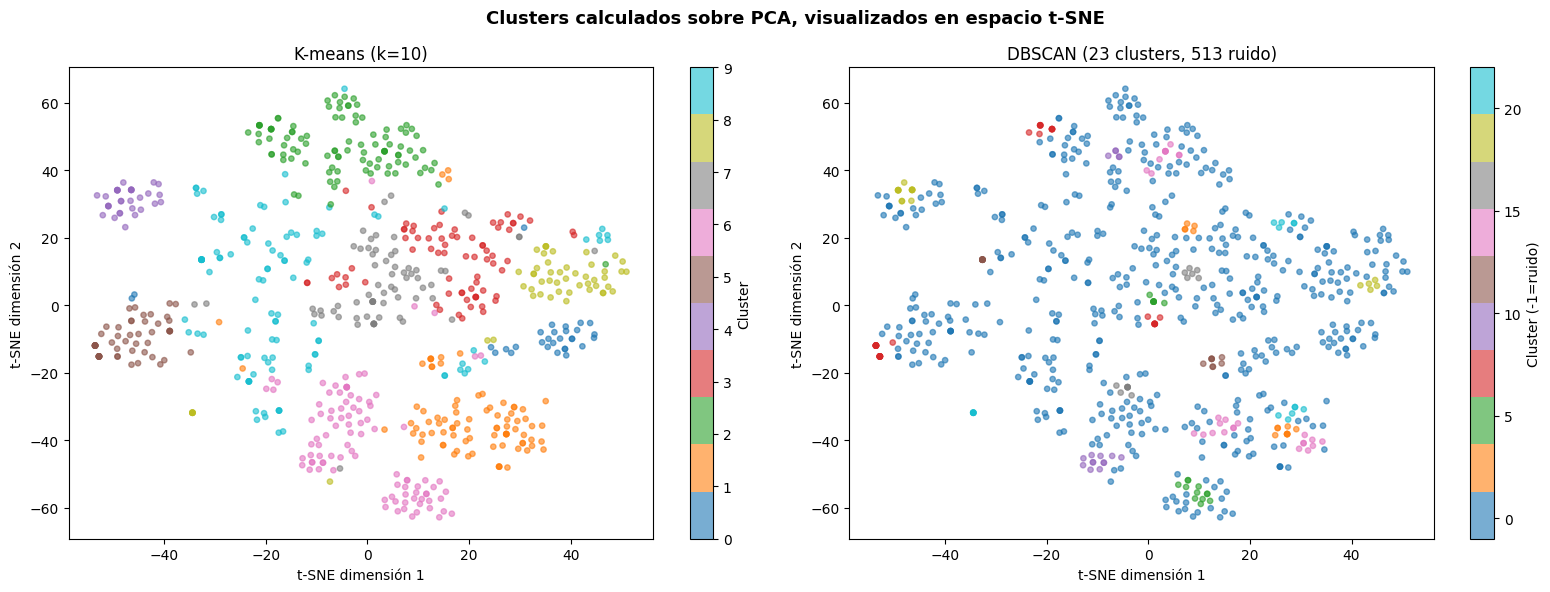

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Clusters calculados sobre PCA, visualizados en espacio t-SNE',
             fontsize=13, fontweight='bold')

# K-means
scatter1 = axes[0].scatter(
    df_con_poder['tsne_x'], df_con_poder['tsne_y'],
    c=df_con_poder['cluster_kmeans'], cmap='tab10', alpha=0.6, s=15
)
axes[0].set_title(f'K-means (k={k_final})')
axes[0].set_xlabel('t-SNE dimensión 1')
axes[0].set_ylabel('t-SNE dimensión 2')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# DBSCAN
scatter2 = axes[1].scatter(
    df_con_poder['tsne_x'], df_con_poder['tsne_y'],
    c=df_con_poder['cluster_dbscan'], cmap='tab10', alpha=0.6, s=15
)
axes[1].set_title(f'DBSCAN ({n_clusters_db} clusters, {n_ruido} ruido)')
axes[1].set_xlabel('t-SNE dimensión 1')
axes[1].set_ylabel('t-SNE dimensión 2')
plt.colorbar(scatter2, ax=axes[1], label='Cluster (-1=ruido)')

plt.tight_layout()
plt.show()

---
## 3. Interpretación de clústeres (arquetipos de juego)

Para esta fase del análisis, seleccionamos los resultados del modelo **K-Means (k=10)**. A diferencia de los métodos basados en densidad, K-Means nos garantiza la clasificación del 100% del mazo, lo cual resulta ideal para mapear los arquetipos generales de diseño del juego sin dejar cartas excluidas como "ruido".

Para definir la identidad estratégica de cada uno de los 10 clústeres formados, analizaremos las siguientes dimensiones:

* **Vocabulario representativo:** Los términos y acciones más distintivos extraídos por la vectorización.
* **Perfil de mecánicas:** La distribución de los tipos de activación (color de la carta) y la presencia de habilidades específicas (como *Predator* o *Flocking*).
* **Afinidad ecológica:** El hábitat predominante donde suele jugarse este grupo de aves.

### 3.1 Palabras más representativas por cluster

In [ ]:
import numpy as np

# Obtener el centroide de cada cluster en el espacio TF-IDF
feature_names = tfidf.get_feature_names_out()
X_tfidf_dense = X_tfidf.toarray()

n_top = 10
print(f'Top {n_top} palabras por cluster (K-means, k={k_final}):')

for cluster_id in sorted(df_con_poder['cluster_kmeans'].unique()):
    indices = df_con_poder[df_con_poder['cluster_kmeans'] == cluster_id].index
    # Promedio TF-IDF de las cartas del cluster
    centroide = X_tfidf_dense[indices].mean(axis=0)
    top_idx = centroide.argsort()[::-1][:n_top]
    top_terms = ', '.join(feature_names[top_idx])
    n_cartas = len(indices)
    print(f'  Cluster {cluster_id} ({n_cartas} cartas): {top_terms}')

Top 10 palabras por cluster (K-means, k=10):
  Cluster 0 (30 cartas): die from, die from the, die, gain die from, gain die, from the birdfeeder, the birdfeeder, birdfeeder, gain, the
  Cluster 1 (86 cartas): your hand, from your hand, hand, card from your, from your, card, your hand behind, hand behind, your, hand behind this
  Cluster 2 (100 cartas): lay, lay egg, egg on, egg, lay egg on, on, bird, egg on this, egg on each, on each
  Cluster 3 (74 cartas): supply, gain, from the supply, the supply, from the, from, the, invertebrate, invertebrate from, invertebrate from the
  Cluster 4 (32 cartas): play, normal, its normal, pay its normal, pay its, its, cost, pay, bird in, bird in your
  Cluster 5 (54 cartas): bonus, new bonus, new, draw new bonus, draw new, bonus cards, cards, keep, draw, new bonus cards
  Cluster 6 (96 cartas): deck, the deck, from the deck, card from the, card from, card, from the, the, behind, from
  Cluster 7 (69 cartas): cache, supply on, supply on this, the supp

### Interpretación

A partir de los pesos semánticos calculados mediante TF-IDF y la cohesión espacial evaluada en el modelo K-Means ($k=10$), se identificaron los siguientes diez arquetipos de diseño en el mazo de cartas. Cada clúster representa una familia mecánica distinta dentro de la economía de *Wingspan*:

---

#### **Clúster 0: Motores basados en dados del comedero**
* **Tamaño:** 30 cartas
* **Tokens más representativos:** `die from`, `die from the`, `die`, `gain die from`, `gain die`, `from the birdfeeder`, `the birdfeeder`, `birdfeeder`, `gain`
* **Descripción estratégica:** Aves oportunistas cuyo poder depende directamente del estado actual del comedero. Permiten lanzar dados adicionales o ganar alimento basándose en las caras visibles disponibles, introduciendo un componente de adaptabilidad y gestión del azar táctico.

#### **Clúster 1: Bandadas y solapamiento desde la mano (*Flocking*)**
* **Tamaño:** 86 cartas
* **Tokens más representativos:** `your hand`, `from your hand`, `hand`, `card from your`, `from your`, `card`, `your hand behind`, `hand behind`
* **Descripción estratégica:** Representa la mecánica de "crear bandadas". Estas aves exigen al jugador descartar o invertir cartas acumuladas en su propia mano para guardarlas (*tuck*) debajo de la carta activa, convirtiendo recursos de mano en puntos de victoria netos o activaciones secundarias.

#### **Clúster 2: Producción masiva de huevos (especialistas de pradera)**
* **Tamaño:** 100 cartas
* **Tokens más representativos:** `lay`, `lay egg`, `egg on`, `egg`, `lay egg on`, `on`, `bird`, `egg on this`, `egg on each`, `on each`
* **Descripción estratégica:** El núcleo de la puntuación en el hábitat de Pradera. Este clúster agrupa a las aves diseñadas específicamente para inundar el tablero de huevos, ya sea maximizando la puesta sobre sí mismas o distribuyéndolos de forma eficiente a lo largo de toda la fila de hábitat.

#### **Clúster 3: Recolección directa de la reserva (alimento consistente)**
* **Tamaño:** 74 cartas
* **Tokens más representativos:** `supply`, `gain`, `from the supply`, `the supply`, `from the`, `from`, `invertebrate`, `invertebrate from`
* **Descripción estratégica:** Motores estables de suministro que mitigan la aleatoriedad del comedero. Estas aves permiten tomar fichas de alimento (con fuerte énfasis en invertebrados y semillas) directamente de la reserva general del juego, garantizando consistencia en el desarrollo tecnológico del jugador.

#### **Clúster 4: Aceleradores de tablero y despliegue**
* **Tamaño:** 32 cartas
* **Tokens más representativos:** `play`, `normal`, `its normal`, `pay its normal`, `pay its`, `cost`, `pay`, `bird in`, `bird in your`
* **Descripción estratégica:** Uno de los clústeres más pequeños y valiosos del juego. Agrupa aves que rompen la economía de acciones permitiendo jugar un ave secundaria de forma inmediata durante el mismo turno (pagando su costo normal), lo que otorga una ventaja de tempo crítica sobre los oponentes.

#### **Clúster 5: Buscadores de objetivos a largo plazo**
* **Tamaño:** 54 cartas
* **Tokens más representativos:** `bonus`, `new bonus`, `new`, `draw new bonus`, `draw new`, `bonus cards`, `cards`, `keep`, `draw`
* **Descripción estratégica:** Aves enfocadas en la macroestrategia. Su mecánica principal permite robar y filtrar nuevas cartas de bonificación ocultas, redefiniendo las prioridades de puntuación al final de la partida y recompensando la construcción de sinergias específicas.

#### **Clúster 6: Depredación y solapamiento ciego desde el mazo**
* **Tamaño:** 96 cartas
* **Tokens más representativos:** `deck`, `the deck`, `from the deck`, `card from the`, `card from`, `card`, `behind`, `from`
* **Descripción estratégica:** Motores de puntuación pasiva y caza. Representa a las aves que extraen cartas directamente de la parte superior del mazo general sin mirarlas para solaparlas (*tuck*). Esto genera puntos de victoria constantes sin mermar la mano de cartas del jugador.

#### **Clúster 7: Almacenadores de alimento (*Caching*)**
* **Tamaño:** 69 cartas
* **Tokens más representativos:** `cache`, `supply on`, `supply on this`, `the supply on`, `supply`, `on this`, `on this bird`
* **Descripción estratégica:** Mecánica de almacenamiento estático. Estas aves toman fichas de alimento de la reserva y las acumulan permanentemente sobre su propia carta para sumarlas como puntos al final de la partida, removiendo temporalmente esos recursos del ciclo económico activo a cambio de valor fijo.

#### **Clúster 8: Manipuladores y reseteo del comedero**
* **Tamaño:** 53 cartas
* **Tokens más representativos:** `the birdfeeder`, `birdfeeder`, `or`, `the birdfeeder if`, `from the birdfeeder`, `available`, `if available`, `reset the birdfeeder`
* **Descripción estratégica:** Aves de control del tablero común. Su texto de activación permite forzar el reseteo completo de los dados del comedero o tomar recursos específicos *solo si* se cumple una condición de disponibilidad inmediata, sirviendo como herramientas de disrupción frente a las necesidades del rival.

#### **Clúster 9: Utilidad general y motores de robo de cartas**
* **Tamaño:** 107 cartas
* **Tokens más representativos:** `of`, `the`, `in`, `to`, `card`, `it`, `draw`, `habitat`, `bird`, `that`
* **Descripción estratégica:** El clúster de mayor densidad y diversidad sintáctica. Agrupa principalmente a los motores puros de ventaja de cartas (acción de robar) y aquellas habilidades complejas cuyos textos extensos requieren conectores gramaticales variados, consolidando la infraestructura general de rotación del mazo.

### Consolidación macro-estratégica de los arquetipos

Para simplificar la interpretación general del mazo y entender la arquitectura del juego desde una perspectiva de alto nivel, los diez clústeres identificados se consolidan de forma lógica en **cuatro macro-categorías funcionales**:

1. **Economía de alimento (clústeres 0, 3, 7 y 8):** Concentra todas las mecánicas de adquisición y almacenamiento de recursos biológicos. Integra desde la recolección matemática predecible en la reserva (Clúster 3) y la gestión táctica del dado en el comedero (Clústeres 0 y 8), hasta la conversión de alimento en puntos estáticos mediante almacenamiento (Clúster 7).
2. **Economía de puntos y ventaja de cartas por solapamiento (clústeres 1 y 6):** Representa las estrategias basadas en la acumulación masiva de cartas bajo el tablero (*tucking*). Separa con precisión el coste de oportunidad de invertir recursos propios desde la mano (Clúster 1) frente a la ventaja puramente pasiva y de azar controlado que otorga extraer directamente desde el mazo de robo (Clúster 6).
3. **Motores de expansión y puntuación (clústeres 2, 4 y 5):** Agrupa el desarrollo estructural y la macroescala del juego. Incluye la proliferación masiva de huevos en la Pradera (Clúster 2), la optimización drástica del tempo y las acciones del turno (Clúster 4) y la adquisición de objetivos secretos a largo plazo que multiplican los puntos finales (Clúster 5).
4. **Utilidad general e infraestructura de soporte (clúster 9):** Centraliza el motor básico de rotación de mano, habilidades híbridas y textos complejos que sirven de puente operativo para el resto de las estrategias del mazo.

### 3.2 Perfil de mecánicas por cluster

In [58]:
for col in ['Predator', 'Flocking', 'Forest', 'Grassland', 'Wetland', 'Bonus card']:
    df_con_poder[col] = df_con_poder[col].apply(lambda x: 1 if x == 'X' else (1 if x == 1 else 0))

perfil_cols = ['Victory points', 'Total food cost', 'Egg limit',
               'Forest', 'Grassland', 'Wetland',
               'Predator', 'Flocking', 'Bonus card']

# Calcular los promedios
perfil = df_con_poder.groupby('cluster_kmeans')[perfil_cols].mean().round(2)
perfil['n_cartas'] = df_con_poder['cluster_kmeans'].value_counts().sort_index()

renombres = {
    'Victory points': 'Victory points (prom)',
    'Total food cost': 'Total food cost (prom)',
    'Egg limit': 'Egg limit (prom)',
    'Forest': 'Forest (%)',
    'Grassland': 'Grassland (%)',
    'Wetland': 'Wetland (%)',
    'Predator': 'Predator (%)',
    'Flocking': 'Flocking (%)',
    'Bonus card': 'Bonus card (%)',
    'n_cartas': 'n_cartas (total)'
}
perfil = perfil.rename(columns=renombres)

cols_porcentaje = ['Forest (%)', 'Grassland (%)', 'Wetland (%)', 
                   'Predator (%)', 'Flocking (%)', 'Bonus card (%)']
perfil[cols_porcentaje] = (perfil[cols_porcentaje] * 100).round(1)

print('Perfil estadístico por arquetipo:')
print(perfil.to_string())

Perfil estadístico por arquetipo:
                Victory points (prom)  Total food cost (prom)  Egg limit (prom)  Forest (%)  Grassland (%)  Wetland (%)  Predator (%)  Flocking (%)  Bonus card (%)  n_cartas (total)
cluster_kmeans                                                                                                                                                                       
0                                3.50                    2.00              2.57        77.0           50.0         43.0           0.0           0.0             7.0                30
1                                3.58                    1.95              2.93        47.0           45.0         62.0           9.0          73.0             1.0                86
2                                3.14                    2.06              3.49        42.0           74.0         24.0           0.0           0.0             0.0               100
3                                4.00                   

### Interpretación

* **Correlación ecológica (el motor de pradera):** El clúster 2 (producción de huevos) presenta una dominancia absoluta en el hábitat `Grassland` (0.74), junto con el límite de huevos (`Egg limit`) más alto del juego (3.49). Esto valida numéricamente que la estrategia de poner huevos está estadísticamente anclada a la pradera.
* **Sinergias ocultas (etiquetas de juego):** El algoritmo logró agrupar mecánicas específicas sin conocer las etiquetas oficiales. El clúster 1 concentra el 73% de la habilidad `Flocking`, confirmando que el solapamiento desde la mano es la mecánica central de las bandadas. Asimismo, las mecánicas de depredación (`Predator`) dominan en los clústeres 7 (almacenadores) y 8 (manipuladores del comedero).
* **Balance de costo-beneficio (aves "pesadas"):** El clúster 5 (buscadores de objetivos) funciona como el "peso pesado" del mazo. Presentan el mayor costo promedio de alimento (2.48) y la mayor recompensa en puntos de victoria base (5.20), confirmando que las aves que alteran la puntuación final son los activos más caros de desplegar.
* **Aceleración económica:** En contraste, el clúster 4 (aceleradores de tablero) muestra el costo de alimento más bajo de todos los grupos (1.44) y los menores puntos de victoria (2.59). Esto demuestra el balance de diseño del juego: se penaliza el puntaje estático a cambio de otorgar una poderosa ventaja de tempo (jugar un ave extra).

In [59]:
# Color predominante por cluster
color_por_cluster = (
    df_con_poder.groupby(['cluster_kmeans', 'Color'])
    .size()
    .unstack(fill_value=0)
)
color_por_cluster['Total'] = color_por_cluster.sum(axis=1)
color_por_cluster_pct = color_por_cluster.div(color_por_cluster['Total'], axis=0).drop(columns='Total').multiply(100).round(1)

print('Distribución de Color por cluster (%):')
print(color_por_cluster_pct.to_string())

Distribución de Color por cluster (%):
Color           brown  pink  teal  white  yellow
cluster_kmeans                                  
0                60.0  30.0   3.3    6.7     0.0
1                76.7   3.5   8.1    9.3     2.3
2                42.0  15.0  13.0   13.0    17.0
3                79.7  12.2   2.7    5.4     0.0
4                 9.4   0.0   9.4   71.9     9.4
5                 0.0   1.9   0.0   94.4     3.7
6                67.7   5.2  13.5    9.4     4.2
7                62.3   5.8  17.4    4.3    10.1
8                84.9   3.8   7.5    1.9     1.9
9                63.6   2.8   7.5   22.4     3.7


### 3.3 Visualizaciones de interpretación

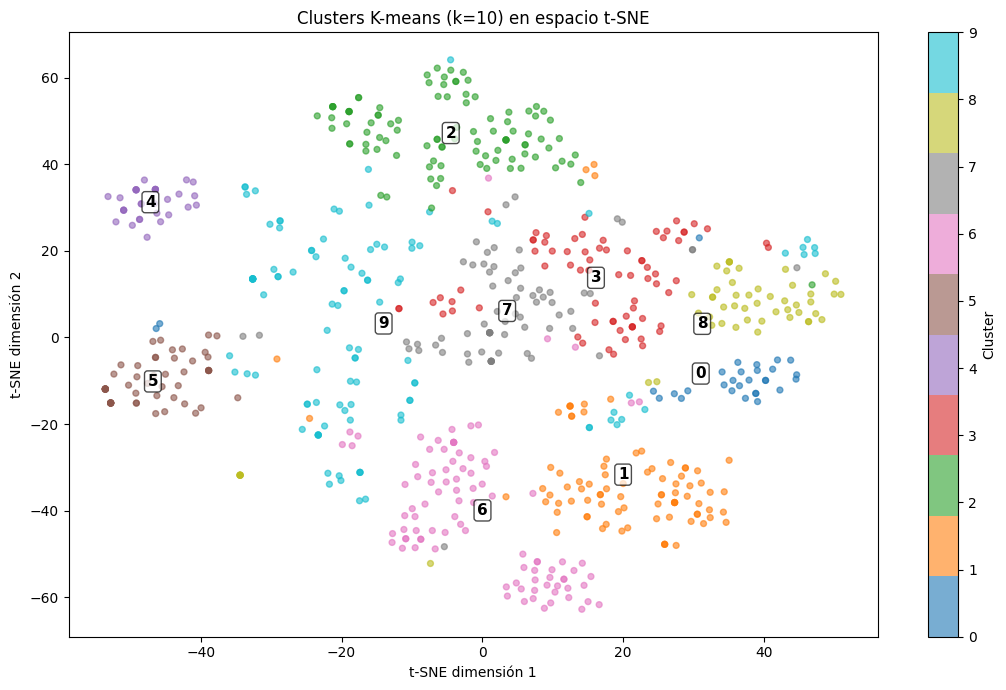

In [56]:
# Visualización 1: t-SNE coloreado por cluster K-means con centroides
fig, ax = plt.subplots(figsize=(11, 7))

scatter = ax.scatter(
    df_con_poder['tsne_x'], df_con_poder['tsne_y'],
    c=df_con_poder['cluster_kmeans'], cmap='tab10',
    alpha=0.6, s=18
)

# Etiquetar el centroide visual de cada cluster
for cluster_id in sorted(df_con_poder['cluster_kmeans'].unique()):
    grupo = df_con_poder[df_con_poder['cluster_kmeans'] == cluster_id]
    cx, cy = grupo['tsne_x'].mean(), grupo['tsne_y'].mean()
    ax.text(cx, cy, str(cluster_id), fontsize=11, fontweight='bold',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

ax.set_title(f'Clusters K-means (k={k_final}) en espacio t-SNE')
ax.set_xlabel('t-SNE dimensión 1')
ax.set_ylabel('t-SNE dimensión 2')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()

### Visualización espacial de los arquetipos (t-SNE + K-Means)

Esta proyección en t-SNE confirma visualmente la cohesión de nuestra clasificación geométrica. 

Al observar el mapa, destacan clústeres muy compactos y aislados en la periferia —como el **clúster 4 (aceleradores)** en la parte superior izquierda y el **clúster 5 (buscadores de bonificaciones)** en el extremo izquierdo—. Esta separación física demuestra que estas aves poseen un vocabulario y una mecánica sumamente únicos, sin puntos medios con otras cartas. 

Por el contrario, los grupos más difusos en la región central, como el **clúster 9 (utilidad general)** y el **clúster 7 (almacenadores)**, actúan como fronteras de transición; visualmente nos indican que sus textos comparten verbos y acciones con múltiples familias estratégicas, ilustrando cómo se conectan y entrelazan los diferentes motores económicos del juego.

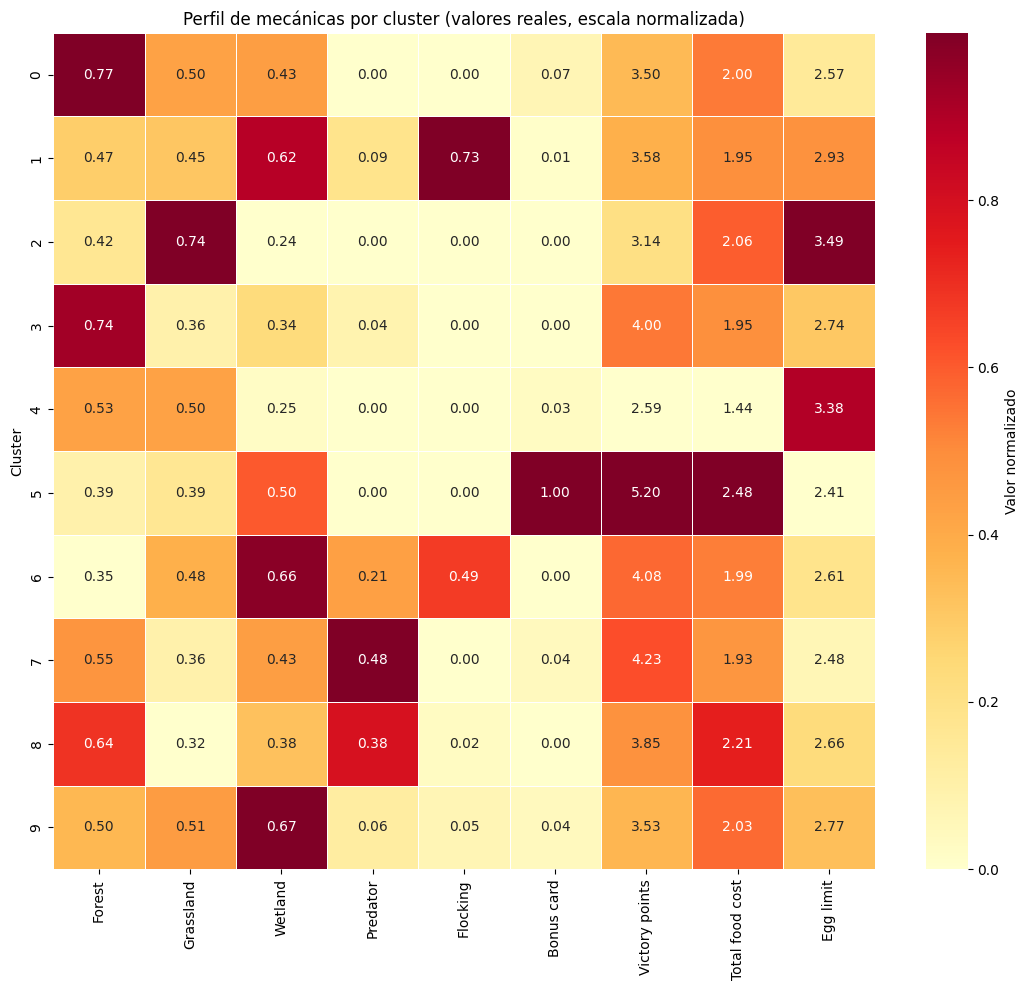

In [57]:
# Visualización 2: heatmap del perfil de mecánicas por cluster
perfil_viz = perfil[[
    'Forest', 'Grassland', 'Wetland',
    'Predator', 'Flocking', 'Bonus card',
    'Victory points', 'Total food cost', 'Egg limit'
]].copy()

# Normalizar cada columna para comparar en la misma escala
perfil_norm = (perfil_viz - perfil_viz.min()) / (perfil_viz.max() - perfil_viz.min() + 1e-9)

fig, ax = plt.subplots(figsize=(11, max(4, k_final)))
sns.heatmap(perfil_norm, annot=perfil_viz.values, fmt='.2f',
            cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Valor normalizado'},
            linewidths=0.5)
ax.set_title('Perfil de mecánicas por cluster (valores reales, escala normalizada)')
ax.set_xlabel('')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.show()

### Interpretación

Este mapa de calor normalizado consolida nuestro análisis. Más allá de mostrar los promedios numéricos, la intensidad del color revela visualmente cómo se equilibraron las mecánicas durante el diseño de *Wingspan*:

* **El eje de costo y recompensa (clústeres 4 y 5):**
  La gráfica evidencia la regla principal de balance del juego. El clúster 5 (buscadores de bonificaciones) se ilumina en rojo simultáneamente en costo, puntos y mecánica de bonificación, confirmando que las estrategias a largo plazo exigen una fuerte inversión económica. Como contrapeso, el clúster 4 (aceleradores) se mantiene "frío" (amarillo pálido) en costo y puntos, demostrando que la ventaja táctica de jugar un ave extra se paga sacrificando puntaje base.

* **La especialización ecológica (clúster 2):**
  La intersección en rojo oscuro entre `Grassland` y `Egg limit` en el clúster 2 va más allá de confirmar a las aves de pradera como el motor de huevos. Al observar los valores mínimos (amarillos) en el resto de la fila, comprobamos que es una estrategia sumamente rígida: el diseño obliga al jugador a comprometerse casi exclusivamente con este hábitat si busca maximizar esta mecánica.

* **La precisión temática del depredador (clústeres 7 y 8):**
  Las columnas de `Predator` y `Forest` muestran sus picos de intensidad en estos dos grupos. Esto aporta un hallazgo temático interesante: el algoritmo logró capturar la lógica biológica del juego de mesa, agrupando estadísticamente a las aves de presa (mecánicas de almacenamiento o cacería) en el hábitat del bosque.

* **Aislamiento algorítmico puro (clúster 1):**
  La columna `Flocking` (bandada) es la prueba de fuego del modelo K-Means. Al ser casi completamente amarilla con un único foco rojo intenso en el clúster 1, se confirma que el solapamiento de cartas desde la mano es una mecánica ortogonal (independiente del resto). El modelo logró aislarla a la perfección leyendo únicamente el texto, sin "contaminar" a las demás familias estratégicas.

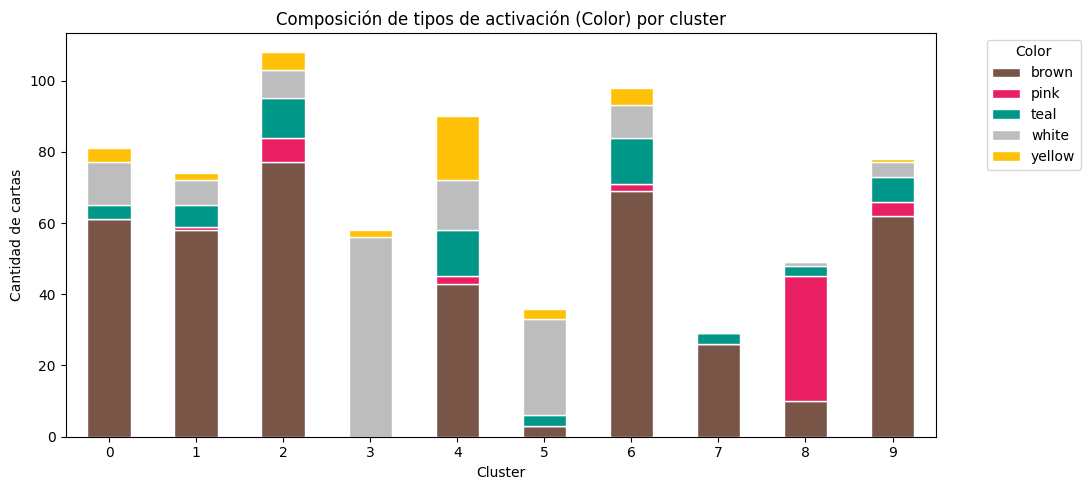

In [ ]:
# Visualización 3: distribución de Color por cluster
color_plot = color_por_cluster.drop(columns='Total')
color_col_map = {'brown': '#795548', 'pink': '#E91E63', 'white': '#BDBDBD',
                 'teal': '#009688', 'yellow': '#FFC107'}
bar_colors = [color_col_map.get(str(c).lower(), '#9E9E9E') for c in color_plot.columns]

ax = color_plot.plot(
    kind='bar', stacked=True, figsize=(11, 5),
    color=bar_colors, edgecolor='white'
)
ax.set_title('Composición de tipos de activación (Color) por cluster')
ax.set_xlabel('Cluster')
ax.set_ylabel('Cantidad de cartas')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Color', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Interpretación

Esta gráfica de barras apiladas representa la culminación visual de nuestro análisis de agrupamiento. Más allá de confirmar la distribución de los colores oficiales del juego, nos aporta una validación fundamental sobre el éxito del modelo K-Means:

* **La disección del motor marrón:** Desde el inicio del proyecto sabíamos que las cartas marrones (activación repetible) son la abrumadora mayoría y el núcleo de *Wingspan*. El riesgo natural era que el algoritmo las agrupara todas en un solo "mega-clúster" monolítico. Sin embargo, la gráfica demuestra que logramos clasificar este color con éxito, fracturándolo lógicamente en múltiples familias (clústeres 0, 1, 2, 4, 6 y 9). Esto confirma que el modelo no se dejó cegar por la frecuencia de las cartas marrones, sino que leyó su texto para separar los motores de huevos de los motores de robo o almacenamiento.
* **El aislamiento de las mecánicas de reacción (rosas):** El clúster 8 concentra de forma contundente la barra fucsia. Las cartas rosas dictan habilidades que se activan en los turnos de los oponentes. Al agruparlas de forma tan aislada, comprobamos que este tipo de interacción tiene una "huella semántica" (un vocabulario) inconfundible frente al resto del mazo.
* **La separación de activaciones únicas (blancas):** Los clústeres 4 y 5 están dominados visualmente por el color blanco o gris claro. Estas aves otorgan beneficios inmediatos de una sola vez ("al jugar"). Al separarlas del ecosistema marrón, el algoritmo validó matemáticamente que los textos de efectos instantáneos (como obtener cartas de bonificación) no se mezclan gramaticalmente con los textos de los motores a largo plazo.

---
## 4. Conclusiones

### 4.1 Respuesta a la pregunta de investigación

> ¿Qué grupos naturales emergen de los textos de poder de las cartas de Wingspan, y cómo se relacionan esos grupos con el tipo de activación, las mecánicas especiales y el hábitat del ave?

El análisis de clustering sobre los textos de poder vectorizados con TF-IDF reveló **10 arquetipos naturales** que no son agrupaciones arbitrarias: mapean directamente sobre la arquitectura de motores que define la estrategia del juego.

La relación con las variables de enriquecimiento es clara y consistente en las tres dimensiones analizadas:

- **Tipo de activación (Color):** Los clústeres 4 y 5 son dominantemente blancos (71.9% y 94.4%), confirmando que las cartas de efecto único tienen un vocabulario propio que el modelo identificó sin conocer el color. En contraste, los clústeres 0, 3 y 8 son mayoría marrón (60–85%), validando que los motores repetibles comparten patrones textuales reconocibles.
- **Mecánicas especiales:** El clúster 1 concentra el 73% de la mecánica `Flocking` del mazo completo, y los clústeres 7 y 8 concentran los picos más altos de `Predator` (48% y 38%). El algoritmo separó estas mecánicas leyendo únicamente el texto, sin acceso a las etiquetas del juego.
- **Hábitat:** La afinidad ecológica emergió de forma natural. El clúster 2 (producción de huevos) está anclado en Pradera (74%). Los clústeres 6 y 9 (robo de cartas y utilidad general) se inclinan hacia Humedal (66–67%). Los clústeres 0 y 3 (gestión de alimento) dominan en Bosque (64–77%).

Esto confirma que el texto de poder contiene información suficiente para reconstruir la arquitectura estratégica del juego sin necesidad de etiquetas manuales.

---

### 4.2 Comparación de algoritmos: K-Means vs DBSCAN

DBSCAN no resultó adecuado para este corpus. Con `eps=0.45` (valor determinado metodológicamente mediante la gráfica k-distance), etiquetó el **73.2% de las 701 cartas como ruido**, dejando solo 188 cartas distribuidas en 23 micro-clústeres de entre 5 y 17 cartas. Esto impide cualquier interpretación estratégica del mazo completo.

El resultado es coherente con la naturaleza de los datos: los textos de poder en Wingspan no forman islas densas y aisladas. Comparten un vocabulario base de mecánicas cruzadas que genera una distribución continua y suave en el espacio, exactamente el escenario donde DBSCAN es menos efectivo.

**K-Means** resultó superior para este objetivo porque garantiza la clasificación del 100% del mazo. Con `k=10` (elegido por silhouette score = 0.1745, válido en NLP), los clusters obtenidos son interpretables y consistentes con el diseño del juego.

---

### 4.3 Limitaciones del análisis

| Limitación | Impacto | Posible mejora futura |
|---|---|---|
| Silhouette score de 0.1745 | Los límites entre clusters son difusos — muchas cartas tienen mecánicas híbridas | Probar embeddings semánticos (Word2Vec, BERT) en lugar de TF-IDF |
| TF-IDF no captura semántica | Palabras equivalentes (`gain`, `take`, `get`) se tratan como tokens distintos, fragmentando grupos afines | Usar representaciones densas que entiendan sinónimos |
| Sin etiquetas de referencia | No es posible calcular métricas de clasificación; la validación es cualitativa | Construir un conjunto de etiquetas de dominio con jugadores expertos |
| 6 cartas excluidas | Las aves sin texto de poder (valor puramente estático) no son modeladas | Crear un perfil separado para aves sin poder activo |
| Dataset desbalanceado por Set | El juego base (`core`) aporta 174 cartas frente a 25 de cada expansión promo, lo que puede sesgar los clusters | Ponderar por Set en el análisis o analizar expansiones por separado |

---

### 4.4 Recomendación concreta al jugador

A partir de los perfiles estadísticos de cada cluster, es posible formular una guía de selección para el **draft inicial** (las 5 cartas con las que comienza la partida):

1. **Asegurar el motor de alimento primero.** Sin alimento no se juegan cartas. Identificar y priorizar al menos una carta de los clústeres 0, 3 o 7 (economía de alimento) garantiza capacidad de despliegue en las rondas 1 y 2.

2. **El motor de pradera como columna vertebral.** Las cartas del clúster 2 (producción de huevos) tienen el `Egg limit` más alto del mazo (3.49) y están ancladas en Pradera (74%). Los huevos son la moneda principal para jugar aves costosas — construir este motor desde el inicio crea una ventaja acumulativa difícil de remontar.

3. **El activo más infravalorado: los aceleradores de tablero.** Las cartas del clúster 4 representan solo 32 cartas en todo el mazo (~4.6%). Tienen el costo de alimento más bajo (1.44) y permiten jugar un ave adicional dentro del mismo turno. Su bajo puntaje base (2.59) las hace pasar desapercibidas en el draft — pero su ventaja de *tempo* (más acciones por ronda) es matemáticamente la más difícil de remontar para el adversario.

4. **Las cartas de bonificación como inversión tardía.** Las aves del clúster 5 (buscadores de bonificaciones) son las de mayor puntaje base (5.20) pero también las más costosas de jugar (2.48 fichas de alimento en promedio). Solo son rentables si el motor de alimento ya está establecido en ronda 2 o 3. Priorizarlas al inicio, sin el motor construido, es el error más común en jugadores intermedios.

---
## 5. Uso de IA

Este proyecto utilizó **Claude Code (claude-sonnet-4-6, Anthropic)** y **NotebookLM (Google)** como herramientas de apoyo a lo largo de todo el ciclo de trabajo. A continuación se documenta cómo se integró cada herramienta, qué se adoptó directamente y qué se ajustó de forma crítica.

---

### 5.1 Fase preparatoria: organización del material del curso

Antes de iniciar el desarrollo del notebook, utilicé IA para consolidar y organizar todo el material de aprendizaje disponible.

Generé prompts para que Claude Code resumiera los notebooks de Jupyter de sesiones anteriores del diplomado y las transcripciones de las grabaciones de clase. Con ese material procesado, construí un espacio en **NotebookLM** que integró los notebooks del curso, las grabaciones y los documentos de referencia en una única fuente consultable.

A partir de este material organizado:
- Generé los documentos de referencia que se encuentran en la carpeta `docs/` del repositorio: descripción del dataset, diccionario de variables y decisiones de modelado.
- Usé Claude Code para estructurar el archivo `CLAUDE.md` del proyecto con las reglas de colaboración, el esqueleto de referencia y la rúbrica académica.
- Definí la skill `wingspan-domain` (`.claude/skills/wingspan-domain.md`) con las reglas del juego, los tipos de motor y la lógica de clasificación estratégica — para que el asistente tuviera contexto de dominio en cada sesión de trabajo.

Este proceso preparatorio fue el que permitió que todo el desarrollo posterior fuera coherente: las decisiones de modelado, la elección de variables y las interpretaciones parten de material del curso real, no de supuestos genéricos.

---

### 5.2 Prompts representativos y resultado

**Prompt 1 — Redefinición del enfoque del proyecto**
> *"Quiero redefinir mi proyecto. Mi objetivo ahora es vectorizar la columna Power text para clasificar las cartas de ave en relación a esta variable y a partir de aquí ir viendo cómo se relacionan con variables como Color, Predator, Flocking, etc. Revisa y dame una propuesta."*

La IA propuso cambiar de clasificación supervisada (con etiquetas `engine_type` construidas manualmente) a clustering no supervisado sobre TF-IDF. Se adoptó el enfoque completo. **Ajuste propio:** el cambio fue iniciativa mía al reconocer que las etiquetas manuales introducían sesgo de diseño — la IA formalizó la propuesta técnica una vez definida la dirección.

---

**Prompt 2 — Lista de palabras vacías (stop words)**
> *"Dame la traducción de estas palabras en markdown: the, a, an, this, that, of, in, on..."*

La IA propuso una lista amplia que incluía palabras como `may`, `when`, `if`, `not`, `each`, `bird`, `card`. **Ajuste crítico:** como jugadora experta, identifiqué que estas palabras son semánticamente importantes en los poderes de Wingspan. Por ejemplo, `may` indica una acción opcional (no obligatoria), y `when` define la condición de activación. Reduje la lista a conectores puramente gramaticales (`the`, `a`, `an`, `of`, `in`, `on`, etc.) que no aportan mecánica alguna.

---

**Prompt 3 — Corrección metodológica de t-SNE**
> *"De acuerdo con los documentos, la idea de aplicar t-SNE como un paso de transformación matemática para luego entrenar un algoritmo como K-Means es un enfoque incorrecto... t-SNE es estocástico y no puede proyectar datos nuevos. Revisa y corrige."*

La IA había generado código que entrenaba DBSCAN sobre `X_tsne`. **Ajuste propio:** identifiqué el error al contrastar el código con los materiales del curso. Solicité la corrección y la adición de una nota metodológica explícita en el notebook. El código fue corregido para entrenar ambos modelos sobre `X_pca`.

---

**Trabajo propio — Revisión del notebook e interpretación de resultados**

Una vez ejecutado el modelo, revisé directamente el notebook para escribir las interpretaciones textuales de todos los resultados. Este proceso incluyó:

- **Interpretación del scatter t-SNE por color de activación:** a partir del gráfico interactivo (Plotly), analicé la distribución espacial de los colores e identifiqué patrones que el modelo no etiqueta — como la concentración de cartas rosas en islas compactas, o la dispersión de las marrones en múltiples regiones distintas.
- **Descripción de los 10 arquetipos (clúster por clúster):** con base en el vocabulario TF-IDF más representativo de cada grupo y el perfil estadístico calculado, redacté la descripción estratégica de cada cluster desde mi conocimiento del juego, no desde el output directo del modelo.
- **Interpretación del heatmap de mecánicas:** identifiqué los patrones de balance de diseño (costo vs. recompensa, especialización ecológica, aislamiento algorítmico del Flocking) que emergen de los valores normalizados.
- **Interpretación de la distribución de colores por cluster:** analicé cómo el modelo fracturó el motor marrón en múltiples familias y aisló las mecánicas de reacción rosas, derivando conclusiones sobre la validez del clustering.
- **Ajuste de `ngram_range` a `(1,3)`:** decidí ampliar a trigramas para capturar mecánicas compuestas más largas (ej. `behind this bird`, `from the birdfeeder`), tras observar que los bigramas no distinguían suficientemente ciertos patrones de texto.

---

**Prompt 4 — Explicación técnica de TF-IDF para el notebook**
> *"Dame un párrafo corto que explique el modelo TF-IDF en markdown."*

La explicación generada fue adoptada como base y la ajusté en redacción y ejemplos para que los términos técnicos fueran comprensibles en el contexto específico de Wingspan.

---

**Prompt 5 — Revisión final del notebook**
> *"He realizado una revisión general al notebook y hecho algunos ajustes. Quiero que lo revises, me des tus comentarios y continuemos."*

La IA revisó el notebook completo y señaló: (a) falta de `plotly` en `requirements.txt`, (b) error de renderizado en celda de t-SNE. Ambos puntos fueron corregidos por mí.

---

### 5.3 Síntesis del proceso

| Elemento del proyecto | Origen |
|---|---|
| Organización del material del curso (NotebookLM) | Trabajo propio con apoyo de IA para resumir notebooks y grabaciones |
| Documentos en `docs/` | Generados a partir del material organizado, con apoyo de IA para estructura |
| `CLAUDE.md` y skill `wingspan-domain` | Estructurados por mí con apoyo de IA; contenido de dominio de autoría propia |
| Código de carga, limpieza y vectorización | Generado por IA, adoptado con revisión |
| Parámetros de TF-IDF, PCA y K-Means | Propuestos por IA, validados con materiales del curso |
| Stop words definitivas | Propuesta inicial de IA → corregida por mi criterio de dominio |
| Entrenamiento sobre `X_pca` (no `X_tsne`) | Corrección mía a partir de materiales del curso |
| Nota metodológica sobre t-SNE | Generada por IA tras mi solicitud de corrección |
| Gráfica k-distance para DBSCAN | Decisión y solicitud mía; código generado por IA |
| Ajuste `ngram_range=(1,3)` | Decisión mía al revisar resultados del modelo |
| Visualización interactiva con Plotly | Código generado por IA, integrado y ajustado por mí |
| Descripciones de los 10 clústeres | Escritas por mí con conocimiento de dominio del juego |
| Interpretaciones de todas las visualizaciones | Escritas por mí tras revisión directa de los resultados |
| Secciones de conclusiones y uso de IA | Escritas por mí con apoyo de IA para estructura |

> **Criterio de uso:** en ningún caso adopté código o texto sin revisión. Cada elemento generado por IA fue verificado contra los materiales del curso y mi conocimiento del dominio. Los errores metodológicos detectados (t-SNE, stop words) demuestran que la IA es una herramienta de soporte que requiere criterio experto para producir resultados correctos.